# Submission deep-dive (N episodes, one submission)

Purpose: is a symptom **structural or noise**? Exports a noise-floor dict for `submission_comparison.ipynb`.

**Run all cells** — downloads Kaggle replays and builds the summary JSON automatically when needed (cached under `kaggle_logs/`).

In [9]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "experiments"))

import submission_nb as snb
from agent.pricing import MARKET_PARAMS

SUBMISSION_ID = "56636887" # "55938405"  # TwoLand example; change as needed
US_NAME = "Milos Vlainic"  # Kaggle team name (matches info.TeamNames)
REFRESH = False  # True → re-summarize even if JSON exists
DAYS = list(range(snb.SEASON_DAYS))

In [10]:
summary = snb.ensure_summary(
    SUBMISSION_ID, US_NAME, ROOT, refresh=REFRESH, verbose=True
)
games = summary.get("games") or []
agg = summary.get("aggregate") or {}

print(f"submission={summary.get('submission_id')}  n={summary.get('n_episodes')}")
print(f"us_name={summary.get('us_name')}  seat_counts={agg.get('seat_counts')}")
print(f"win_rate={agg.get('win_rate', 0):.3f}")

rows = [snb.episode_row(g) for g in games]
df_ep = pd.DataFrame(rows)
df_ep.head()

Summarizing 56636887 (us_name='Milos Vlainic')...
Analyzing 1/20 episode-114634785-replay.json
Analyzing 2/20 episode-114636678-replay.json
Analyzing 3/20 episode-114638196-replay.json
Analyzing 4/20 episode-114639712-replay.json
Analyzing 5/20 episode-114641184-replay.json
Analyzing 6/20 episode-114642717-replay.json
Analyzing 7/20 episode-114644159-replay.json
Analyzing 8/20 episode-114645685-replay.json
Analyzing 9/20 episode-114647146-replay.json
Analyzing 10/20 episode-114648679-replay.json
Analyzing 11/20 episode-114649890-replay.json
Analyzing 12/20 episode-114651633-replay.json
Analyzing 13/20 episode-114653145-replay.json
Analyzing 14/20 episode-114654540-replay.json
Analyzing 15/20 episode-114656165-replay.json
Analyzing 16/20 episode-114657714-replay.json
Analyzing 17/20 episode-114659167-replay.json
Analyzing 18/20 episode-114660633-replay.json
Analyzing 19/20 episode-114662142-replay.json
Analyzing 20/20 episode-114663604-replay.json
submission=56636887  n=20
us_name=Milos

,episode_id,seed,reward_us,reward_opp,win,noop_ops,move_overhead,ripe_mean_latency,unexplained_delta,tile_day_utilization,idle_empty,idle_weed,total_hire_spend,days_below_floor,n_steps
0,114634785,0,41543.0,53337.0,False,11,0.734602,32.974249,1804.0,0.561147,12410,208,504,0,720
1,114636678,2023622903,92740.0,116343.0,False,7,0.684268,41.032028,3679.0,0.778621,6455,17,3506,0,720
2,114638196,180125295,67724.0,76995.0,False,8,0.773913,53.022472,6537.0,0.762328,6752,68,2956,0,720
3,114639712,42942202,60461.0,17539.0,True,11,0.755763,33.153488,775.0,0.811111,3381,11,360,0,720
4,114641184,634812445,68044.0,100655.0,False,11,0.731799,34.760684,1156.0,0.732909,6007,61,756,0,720


## 1. Reward me vs opp (colored by my initial skill) + noise floor

Fetching initialScore for 20 episode(s)...
  episode 114642717: us_skill=427.89942291413524
  episode 114638196: us_skill=502.2909186186285
  episode 114641184: us_skill=490.5347939461435
  episode 114634785: us_skill=None
  episode 114645685: us_skill=515.7854914761143
  episode 114639712: us_skill=420.9273571606954
  episode 114636678: us_skill=600
  episode 114644159: us_skill=487.23772356524626
  episode 114651633: us_skill=461.55134766440176
  episode 114654540: us_skill=461.2414321860532
  episode 114656165: us_skill=442.8781756811419
  episode 114647146: us_skill=474.6547301813448
  episode 114648679: us_skill=520.0256358608405
  episode 114657714: us_skill=462.9119327401312
  episode 114653145: us_skill=439.0072110265406
  episode 114649890: us_skill=491.4757024712521
  episode 114659167: us_skill=484.44097892256775
  episode 114660633: us_skill=501.1353405051913
  episode 114663604: us_skill=498.89828700424107
  episode 114662142: us_skill=515.2811852792236
mean=63504  median=

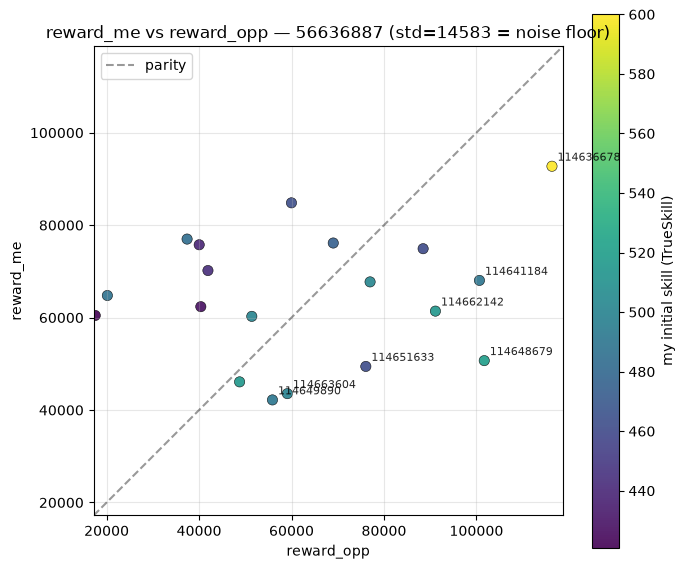

reward_us               14583.073
move_overhead               0.029
noop_ops                    2.012
ripe_mean_latency           7.119
unexplained_delta        1797.604
tile_day_utilization        0.091
total_hire_spend         1281.415
days_below_floor            0.000
score_std               14583.073
Name: std_across_episodes, dtype: float64

In [11]:
skills = snb.ensure_episode_skills(SUBMISSION_ID, games, ROOT, refresh=REFRESH)
snb.attach_skills(games, skills)

df_ep = pd.DataFrame([snb.episode_row(g) for g in games])
df_ep["initial_score_us"] = [g.get("initial_score_us") for g in games]
df_ep["initial_score_opp"] = [g.get("initial_score_opp") for g in games]

rewards = df_ep["reward_us"].dropna().astype(float)
score_std = float(rewards.std()) if len(rewards) > 1 else 0.0
noise_floor = snb.noise_floor_from_games(games)
noise_floor["score_std"] = score_std

print(f"mean={rewards.mean():.0f}  median={rewards.median():.0f}  std={score_std:.0f}")
print(f"win_rate={df_ep['win'].mean():.3f}")

scatter = df_ep.dropna(subset=["reward_us", "reward_opp", "initial_score_us"])
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    scatter["reward_opp"],
    scatter["reward_us"],
    c=scatter["initial_score_us"],
    cmap="viridis",
    s=55,
    edgecolors="k",
    linewidths=0.4,
    alpha=0.9,
)


cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("my initial skill (TrueSkill)")
cbar.ax.set_zorder(0)
ax.set_zorder(1)
ax.patch.set_zorder(-1)

lim_hi = float(max(scatter["reward_us"].max(), scatter["reward_opp"].max())) * 1.02
lim_lo = float(min(scatter["reward_us"].min(), scatter["reward_opp"].min())) * 0.98
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", alpha=0.4, label="parity")
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel("reward_opp")
ax.set_ylabel("reward_me")
ax.set_title(
    f"reward_me vs reward_opp — {SUBMISSION_ID} "
    f"(std={score_std:.0f} = noise floor)"
)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

bad = scatter[
    (scatter["reward_opp"] > 0)
    & (scatter["reward_us"] / scatter["reward_opp"] < 0.8)
]
for _, row in bad.iterrows():
    ax.annotate(
        str(row["episode_id"]),
        (row["reward_opp"], row["reward_us"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        alpha=0.85,
        zorder=10,
        clip_on=False,
    )
plt.tight_layout()
plt.show()

pd.Series(noise_floor, name="std_across_episodes").round(3)


## 2. Day-banded series (mean ± std)

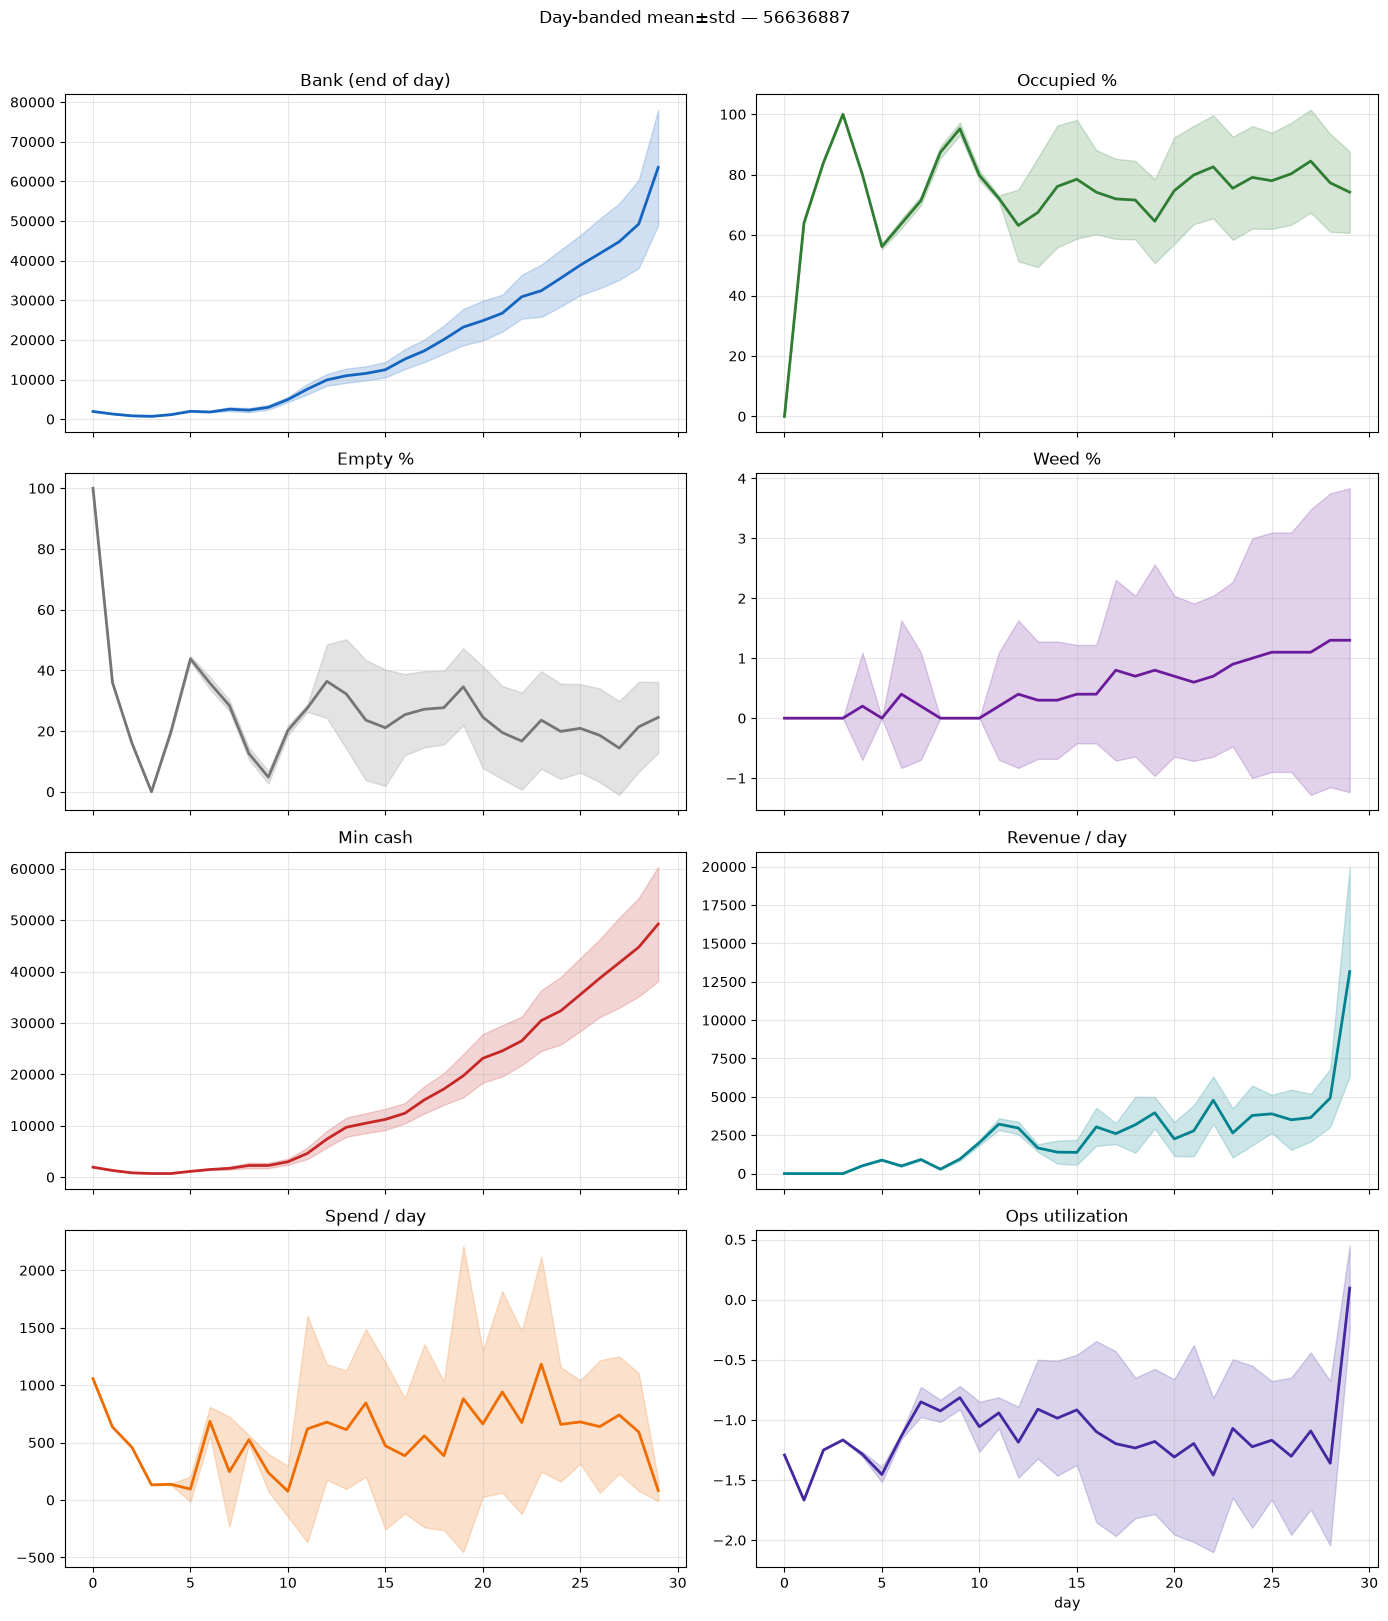

In [12]:
series_specs = [
    ("Bank (end of day)", snb.bank_end_series, "#1565c0"),
    ("Occupied %", snb.occupied_pct_series, "#2e7d32"),
    ("Empty %", lambda g: snb.tile_pct_series(g, "empty"), "#757575"),
    ("Weed %", lambda g: snb.tile_pct_series(g, "weed"), "#6a1b9a"),
    ("Min cash", snb.min_cash_series, "#c62828"),
    ("Revenue / day", snb.revenue_series, "#00838f"),
    ("Spend / day", snb.spend_series, "#ef6c00"),
    ("Ops utilization", snb.ops_util_series, "#4527a0"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.ravel()
for ax, (title, fn, color) in zip(axes, series_specs):
    mean, std = snb.day_band(games, fn)
    m = np.array(mean, dtype=float)
    s = np.array(std, dtype=float)
    ax.plot(DAYS, m, color=color, lw=2)
    ax.fill_between(DAYS, m - s, m + s, color=color, alpha=0.2)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("day")
fig.suptitle(f"Day-banded mean±std — {SUBMISSION_ID}", y=1.01)
plt.tight_layout()
plt.show()

## 3. KPI boxplots across episodes

/tmp/ipykernel_10473/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_10473/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_10473/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_10473/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)


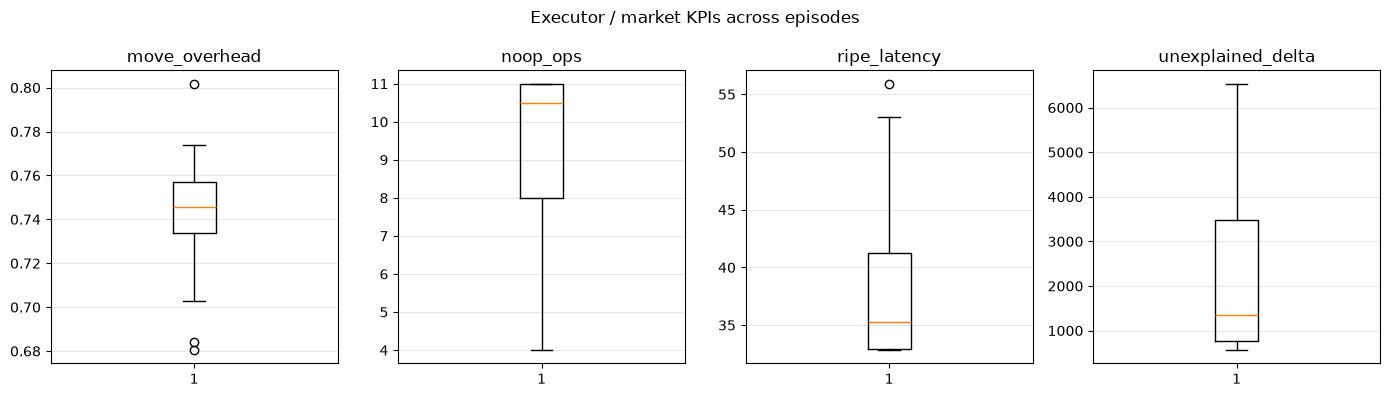

In [13]:
scalar_kpis = [
    ("move_overhead", df_ep["move_overhead"]),
    ("noop_ops", df_ep["noop_ops"]),
    ("ripe_latency", df_ep["ripe_mean_latency"]),
    ("unexplained_delta", df_ep["unexplained_delta"]),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (label, vals) in zip(axes, scalar_kpis):
    ax.boxplot(vals.dropna(), vert=True)
    ax.set_title(label)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Executor / market KPIs across episodes")
plt.tight_layout()
plt.show()

/tmp/ipykernel_10473/22540819.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)
/tmp/ipykernel_10473/22540819.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)


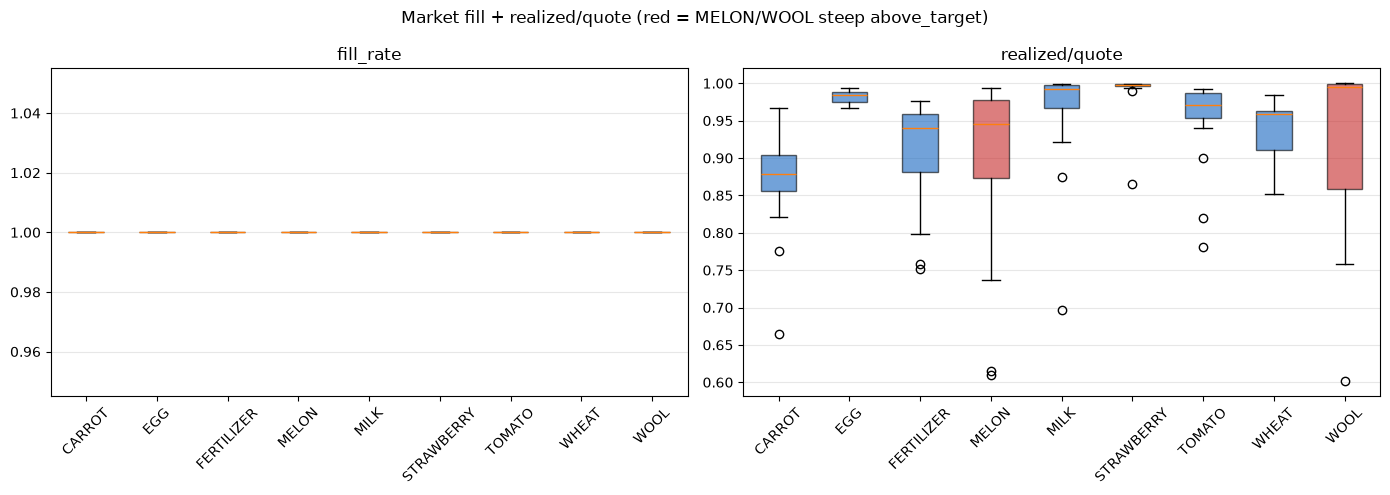

fill_rate      realized_vs_quote          
             mean  std              mean       std
product                                           
MELON         1.0  0.0          0.896086  0.120341
WOOL          1.0  0.0          0.931215  0.112645

In [14]:
# Fill rate + realized/quote per product (MELON & WOOL highlighted)
products = sorted({p for g in games for p in (snb.us_kpi(g)[1].get("fill_rate") or {})})
fill_rows = []
for g in games:
    eid = g.get("episode_id")
    for prod in products:
        fill_rows.append({
            "episode_id": eid,
            "product": prod,
            "fill_rate": snb.fill_rate_for(g, prod),
            "realized_vs_quote": snb.realized_quote_for(g, prod),
            "steep_glut": prod in snb.STEEP_GLUT_PRODUCTS,
            "above_target": getattr(MARKET_PARAMS.get(prod), "above_target", None),
        })
df_fill = pd.DataFrame(fill_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylab in zip(axes, ["fill_rate", "realized_vs_quote"], ["fill_rate", "realized/quote"]):
    data = []
    labels = []
    colors = []
    for prod in products:
        sub = df_fill[df_fill["product"] == prod][col].dropna()
        if len(sub):
            data.append(sub.values)
            labels.append(prod)
            colors.append("#c62828" if prod in snb.STEEP_GLUT_PRODUCTS else "#1565c0")
    bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    ax.set_title(ylab)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Market fill + realized/quote (red = MELON/WOOL steep above_target)")
plt.tight_layout()
plt.show()

df_fill[df_fill["steep_glut"]].groupby("product")[["fill_rate", "realized_vs_quote"]].agg(["mean", "std"])

## 4. Land-purchase timing

,episode_id,seed,day,quadrant,cost,cash_before,cash_after,days_below_floor,reward_us,win
1,114636678,2023622903,11,NE,1000,5142.0,5005.0,0,92740.0,False
5,114645685,1324856389,11,NE,1000,5169.0,7340.0,0,46097.0,False
6,114647146,1309841110,11,NE,1000,5102.0,5087.0,0,76135.0,True
10,114657714,88054014,11,NE,1000,2536.0,4245.0,0,84828.0,True
0,114634785,0,12,NE,1000,8238.0,9711.0,0,41543.0,False
2,114638196,180125295,12,NE,1000,8352.0,10178.0,0,67724.0,False
11,114659167,1323976574,12,NE,1000,7902.0,9577.0,0,76987.0,True
9,114654540,2011312853,13,NE,1000,9955.0,10635.0,0,74907.0,False
7,114649890,115420522,14,NE,1000,11947.0,10964.0,0,42193.0,False
8,114653145,1003799002,15,NE,1000,12854.0,12276.0,0,75756.0,True


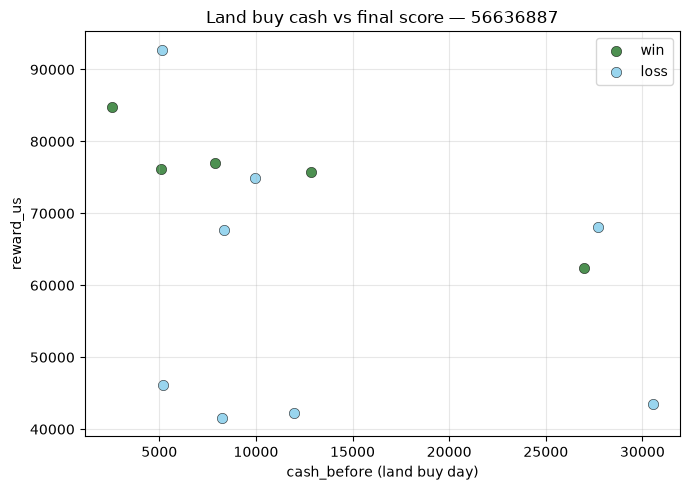

In [15]:
land_rows = []
for g in games:
    land_rows.extend(snb.land_purchase_rows(g))
df_land = pd.DataFrame(land_rows)
if df_land.empty:
    print("No land_events in this submission.")
else:
    display(df_land.sort_values(["day", "episode_id"]))

    plot_df = df_land.dropna(subset=["cash_before", "reward_us", "win"])
    fig, ax = plt.subplots(figsize=(7, 5))
    for won, color, label in [(True, "#2e7d32", "win"), (False, "skyblue", "loss")]:
        sub = plot_df[plot_df["win"] == won]
        if sub.empty:
            continue
        ax.scatter(
            sub["cash_before"],
            sub["reward_us"],
            c=color,
            s=55,
            edgecolors="k",
            linewidths=0.4,
            alpha=0.85,
            label=label,
        )
    ax.set_xlabel("cash_before (land buy day)")
    ax.set_ylabel("reward_us")
    ax.set_title(f"Land buy cash vs final score — {SUBMISSION_ID}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5. Anomaly table

In [16]:
df_anom = pd.DataFrame(snb.anomaly_rows(games))
if df_anom.empty:
    print("No anomalies flagged.")
else:
    display(df_anom)

NOISE_FLOOR = noise_floor
print(f"\nNOISE_FLOOR ready (score_std={NOISE_FLOOR.get('score_std', 0):.0f})")

No anomalies flagged.

NOISE_FLOOR ready (score_std=14583)
